# Машинное обучение для магнитогидродинамики (МГД)
## Обучение на реальных данных из датасета The Well

Этот ноутбук демонстрирует:
1. Загрузку реальных данных МГД из датасета The Well (MHD_64)
2. Понимание уравнений магнитогидродинамики
3. Построение нейронной сети для предсказания эволюции МГД систем
4. Обучение модели и оценку качества предсказаний

## 1. Импорт необходимых библиотек

In [ ]:
# !pip install the_well torch numpy matplotlib tqdm huggingface_hub
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import os
import sys
from pathlib import Path

# PyTorch для ML модели
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Прогресс бар - используем обычный tqdm вместо notebook
from tqdm import tqdm

# Настройка matplotlib
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

# Проверка доступности GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Установка seed для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Используется устройство: cuda


## 2. Загрузка данных МГД из датасета The Well

The Well - это коллекция из 15TB физических симуляций. Датасет MHD_64 содержит 3D симуляции магнитогидродинамики на сетке 64³.

**Способы загрузки данных:**
1. Через `the_well` пакет (рекомендуется)
2. Напрямую с HuggingFace Hub
3. Локальная загрузка

In [2]:
# Установка библиотеки the_well (если еще не установлена)
# !pip install the_well

try:
    from the_well.data import WellDataset
    USE_THE_WELL = True
    print("✓ Пакет the_well доступен")
except ImportError:
    USE_THE_WELL = False
    print("✗ Пакет the_well не установлен. Будем использовать альтернативный метод загрузки.")
    print("Установите: pip install the_well")
# USE_THE_WELL = False

✓ Пакет the_well доступен


In [10]:
# Вариант 1: Загрузка через the_well (рекомендуется)
if USE_THE_WELL:
    try:
        # Можно стримить данные с HuggingFace или загрузить локально
        dataset = WellDataset(
            well_base_path="hf://datasets/polymathic-ai/",  # Стриминг с HF Hub
            well_dataset_name="MHD_64",
            well_split_name="train"
        )
        
        print(f"Датасет загружен: {len(dataset)} образцов")
        
        # Посмотрим на первый образец
        sample = dataset[0]
        print(f"\nФормат образца:")
        print(f"  Ключи: {sample.keys() if isinstance(sample, dict) else 'tensor'}")
        if isinstance(sample, dict):
            for key, val in sample.items():
                if isinstance(val, (torch.Tensor, np.ndarray)):
                    print(f"  {key}: shape = {val.shape}, dtype = {val.dtype}")
        
        # Создаем валидационный датасет
        val_dataset_well = WellDataset(
            well_base_path="hf://datasets/polymathic-ai/",
            well_dataset_name="MHD_64",
            well_split_name="valid"
        )
        print(f"\nВалидационный датасет: {len(val_dataset_well)} образцов")
        
    except Exception as e:
        print(f"Ошибка загрузки: {e}")
        print("Попробуем альтернативный метод...")
        USE_THE_WELL = False

# Вариант 2: Создадим синтетические данные для демонстрации
if not USE_THE_WELL:
    print("\nИспользуем синтетические данные для демонстрации кода")
    print("Для реальных данных установите: pip install the_well")

Датасет загружен: 7623 образцов

Формат образца:
  Ключи: dict_keys(['input_fields', 'output_fields', 'constant_scalars', 'boundary_conditions', 'space_grid', 'input_time_grid', 'output_time_grid'])
  input_fields: shape = torch.Size([1, 64, 64, 64, 7]), dtype = torch.float32
  output_fields: shape = torch.Size([1, 64, 64, 64, 7]), dtype = torch.float32
  constant_scalars: shape = torch.Size([2]), dtype = torch.float32
  boundary_conditions: shape = torch.Size([3, 2]), dtype = torch.float32
  space_grid: shape = torch.Size([64, 64, 64, 3]), dtype = torch.float64
  input_time_grid: shape = torch.Size([1]), dtype = torch.float32
  output_time_grid: shape = torch.Size([1]), dtype = torch.float32

Валидационный датасет: 990 образцов


## 3. Уравнения магнитогидродинамики (МГД)

### Физика МГД

МГД описывает поведение проводящих жидкостей в магнитных полях (плазма, жидкие металлы).

#### Уравнение движения (Модифицированное уравнение Навье-Стокса):
$$\rho (\partial_t \mathbf{v} + (\mathbf{v}\cdot\nabla)\mathbf{v}) = -\nabla p + \mathbf{j}\times\mathbf{B} + \nu \nabla^2\mathbf{v}$$

Где:
- $\mathbf{v}$ - поле скорости
- $\rho$ - плотность
- $p$ - давление
- $\mathbf{j} = \nabla \times \mathbf{B}$ - плотность тока
- $\mathbf{j}\times\mathbf{B}$ - **сила Лоренца** (взаимодействие тока и магнитного поля)
- $\nu$ - кинематическая вязкость

#### Уравнение индукции (Эволюция магнитного поля):
$$\partial_t \mathbf{B} = \nabla\times(\mathbf{v}\times\mathbf{B}) - \nabla\times(\eta\nabla\times\mathbf{B})$$

Где:
- $\mathbf{B}$ - магнитное поле
- $\nabla\times(\mathbf{v}\times\mathbf{B})$ - перенос магнитного поля потоком (вмороженность)
- $\eta$ - магнитная диффузия
- $Rm = VL/\eta$ - магнитное число Рейнольдса

### Упрощенная форма (постоянная плотность):
$$\frac{\partial \mathbf{v}}{\partial t} = -(\mathbf{v}\cdot\nabla)\mathbf{v} + (\nabla\times\mathbf{B})\times\mathbf{B} + \nu\nabla^2\mathbf{v}$$
$$\frac{\partial \mathbf{B}}{\partial t} = \nabla\times(\mathbf{v}\times\mathbf{B}) + \eta\nabla^2\mathbf{B}$$

## 4. Генерация/загрузка тренировочных данных

Для данного датасета МГД данные представлены как временные ряды 3D полей:
- **Поле скорости** $\mathbf{v}(x,y,z,t)$ с компонентами $(v_x, v_y, v_z)$
- **Магнитное поле** $\mathbf{B}(x,y,z,t)$ с компонентами $(B_x, B_y, B_z)$

Размерность: `(время, компоненты, x, y, z)` = `(T, 3, 64, 64, 64)`

In [11]:
def generate_synthetic_mhd_data(n_trajectories=5, n_timesteps=50, nx=64):
    """
    Генерирует синтетические данные МГД для демонстрации.
    В реальном случае эти данные загружаются из The Well датасета.
    """
    print(f"Генерация {n_trajectories} траекторий с {n_timesteps} временными шагами...")
    
    trajectories = []
    for traj_idx in range(n_trajectories):
        # Инициализация случайных полей с гладкой структурой
        v = np.random.randn(n_timesteps, 3, nx, nx, nx).astype(np.float32) * 0.1
        B = np.random.randn(n_timesteps, 3, nx, nx, nx).astype(np.float32) * 0.2
        
        # Простое сглаживание через FFT (имитация физической динамики)
        for t in range(1, n_timesteps):
            # Добавим зависимость от предыдущего шага
            v[t] = 0.95 * v[t-1] + 0.05 * v[t]
            B[t] = 0.95 * B[t-1] + 0.05 * B[t]
        
        trajectories.append({'v': v, 'B': B})
    
    print("✓ Данные сгенерированы")
    return trajectories

# Генерируем или загружаем данные
trajectories = None  # Для синтетических данных

if USE_THE_WELL:
    print("\n✓ Используем реальные данные из The Well")
    print(f"  Train samples: {len(dataset)}")
    print(f"  Val samples: {len(val_dataset_well)}")
    # Данные уже загружены в переменные dataset и val_dataset_well
else:
    print("Генерируем синтетические данные для демонстрации")
    trajectories = generate_synthetic_mhd_data(n_trajectories=8, n_timesteps=40, nx=32)
    print(f"Размер данных одной траектории:")
    print(f"  v: {trajectories[0]['v'].shape}")
    print(f"  B: {trajectories[0]['B'].shape}")


✓ Используем реальные данные из The Well
  Train samples: 7623
  Val samples: 990


## 5. Визуализация данных МГД

Визуализация данных из The Well датасета...
  v shape: (3, 64, 64, 64)
  B shape: (3, 64, 64, 64)


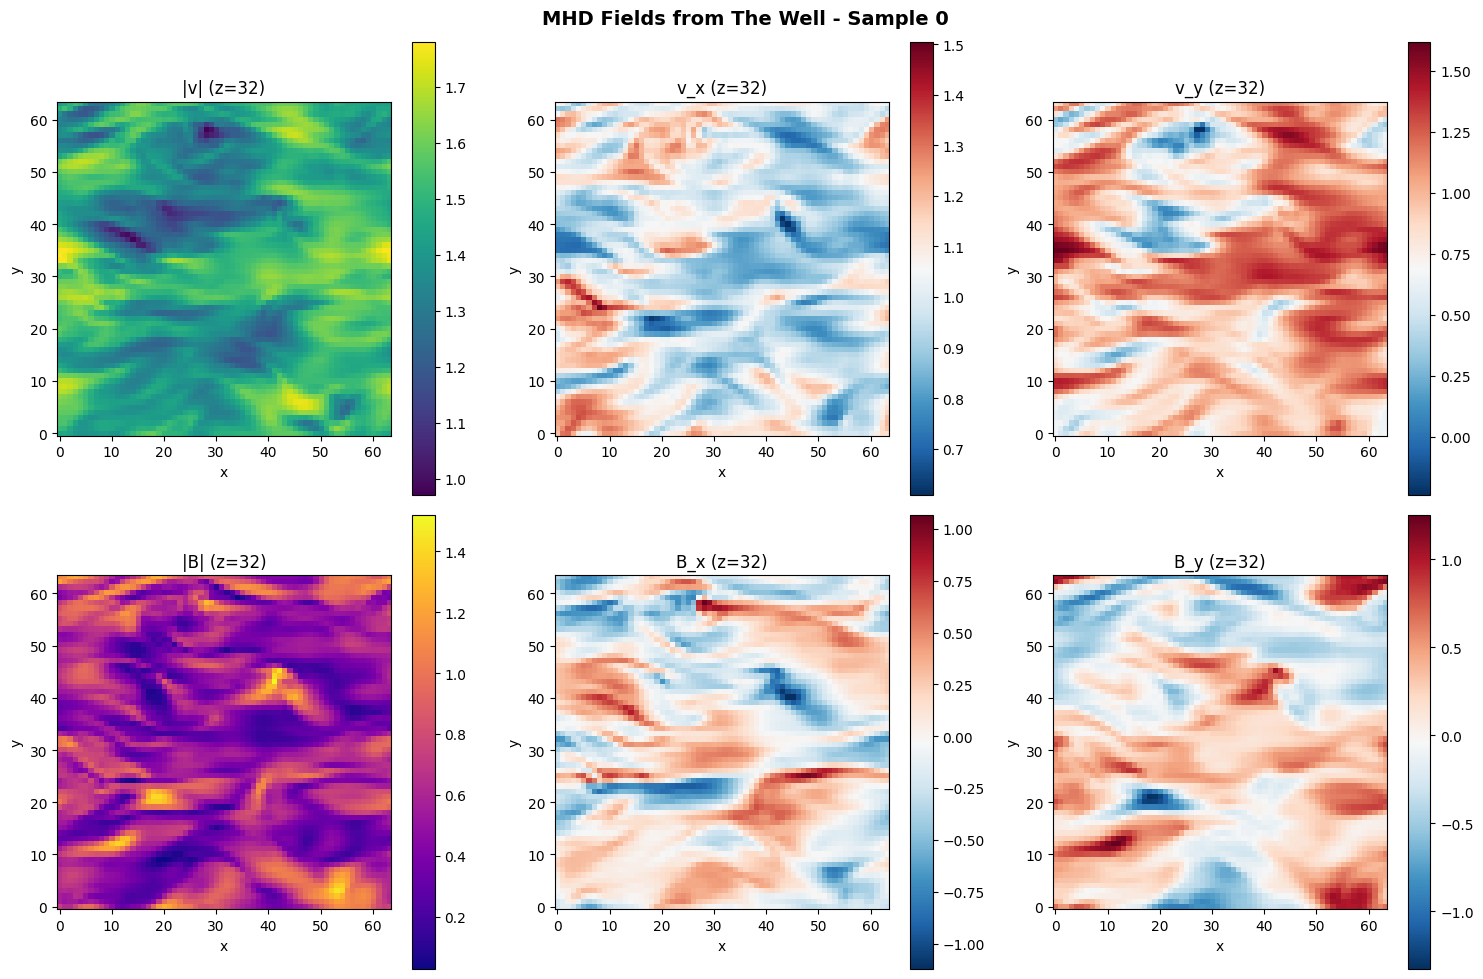

In [12]:
def visualize_mhd_slice(v, B, time_idx=0, z_slice=None, title="MHD Fields"):
    """
    Визуализирует 2D срезы полей скорости и магнитного поля.
    
    v: (T, 3, nx, ny, nz) или (3, nx, ny, nz)
    B: (T, 3, nx, ny, nz) или (3, nx, ny, nz)
    """
    # Если есть временное измерение
    if v.ndim == 5:
        v_slice = v[time_idx]
        B_slice = B[time_idx]
    else:
        v_slice = v
        B_slice = B
    
    nz = v_slice.shape[-1]
    if z_slice is None:
        z_slice = nz // 2
    
    # Вычисляем магнитуды
    v_mag = np.sqrt((v_slice**2).sum(axis=0))  # |v|
    B_mag = np.sqrt((B_slice**2).sum(axis=0))  # |B|
    
    # Визуализация
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Магнитуда скорости
    im0 = axes[0, 0].imshow(v_mag[:, :, z_slice].T, origin='lower', cmap='viridis')
    axes[0, 0].set_title(f'|v| (z={z_slice})')
    axes[0, 0].set_xlabel('x')
    axes[0, 0].set_ylabel('y')
    plt.colorbar(im0, ax=axes[0, 0])
    
    # Компоненты скорости
    for i, comp in enumerate(['x', 'y', 'z']):
        if i < 2:
            im = axes[0, i+1].imshow(v_slice[i, :, :, z_slice].T, origin='lower', cmap='RdBu_r')
            axes[0, i+1].set_title(f'v_{comp} (z={z_slice})')
            axes[0, i+1].set_xlabel('x')
            axes[0, i+1].set_ylabel('y')
            plt.colorbar(im, ax=axes[0, i+1])
    
    # Магнитуда магнитного поля
    im3 = axes[1, 0].imshow(B_mag[:, :, z_slice].T, origin='lower', cmap='plasma')
    axes[1, 0].set_title(f'|B| (z={z_slice})')
    axes[1, 0].set_xlabel('x')
    axes[1, 0].set_ylabel('y')
    plt.colorbar(im3, ax=axes[1, 0])
    
    # Компоненты магнитного поля
    for i, comp in enumerate(['x', 'y', 'z']):
        if i < 2:
            im = axes[1, i+1].imshow(B_slice[i, :, :, z_slice].T, origin='lower', cmap='RdBu_r')
            axes[1, i+1].set_title(f'B_{comp} (z={z_slice})')
            axes[1, i+1].set_xlabel('x')
            axes[1, i+1].set_ylabel('y')
            plt.colorbar(im, ax=axes[1, i+1])
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Визуализация данных
if USE_THE_WELL:
    print("Визуализация данных из The Well датасета...")
    # Берем первый образец
    sample = dataset[0]
    input_fields = sample['input_fields']  # (1, 64, 64, 64, 7)
    
    # Извлекаем поля: (1, 64, 64, 64, 7) -> (7, 64, 64, 64)
    fields = input_fields[0].permute(3, 0, 1, 2).numpy()
    
    # Разделяем на v и B
    v_field = fields[0:3]  # (3, 64, 64, 64) - компоненты скорости
    B_field = fields[3:6]  # (3, 64, 64, 64) - компоненты магнитного поля
    
    print(f"  v shape: {v_field.shape}")
    print(f"  B shape: {B_field.shape}")
    
    visualize_mhd_slice(
        v_field, 
        B_field, 
        z_slice=32,
        title="MHD Fields from The Well - Sample 0"
    )
    
elif trajectories is not None:
    print("Визуализация первой траектории, временной шаг 0:")
    visualize_mhd_slice(
        trajectories[0]['v'], 
        trajectories[0]['B'], 
        time_idx=0,
        title="MHD Fields - Траектория 0, t=0"
    )


## 6. Создание PyTorch Dataset для МГД

Нам нужно создать датасет, который будет возвращать пары (текущее состояние, следующее состояние):
- **Вход**: $(v_t, B_t)$ - состояние в момент $t$ (6 каналов)
- **Выход**: $(\Delta v, \Delta B)$ или $(v_{t+1}, B_{t+1})$ - изменение или следующее состояние

In [13]:
class MHDDataset(Dataset):
    """
    PyTorch Dataset для МГД данных.
    Возвращает пары (current_state, delta) для обучения модели предсказывать изменение.
    """
    def __init__(self, trajectories, predict_delta=True, normalize=True):
        """
        trajectories: список словарей с ключами 'v' и 'B'
                     каждый элемент имеет shape (T, 3, nx, ny, nz)
        predict_delta: если True, предсказываем изменение, иначе следующее состояние
        normalize: нормализовать данные
        """
        self.predict_delta = predict_delta
        self.samples = []
        
        # Собираем все пары (t, t+1)
        for traj in trajectories:
            v = traj['v']  # (T, 3, nx, ny, nz)
            B = traj['B']  # (T, 3, nx, ny, nz)
            
            T = v.shape[0]
            for t in range(T - 1):
                # Текущее состояние: объединяем v и B в один тензор
                state_t = np.concatenate([v[t], B[t]], axis=0)  # (6, nx, ny, nz)
                state_tp1 = np.concatenate([v[t+1], B[t+1]], axis=0)
                
                if predict_delta:
                    target = state_tp1 - state_t  # Предсказываем изменение
                else:
                    target = state_tp1  # Предсказываем следующее состояние
                
                self.samples.append((state_t, target))
        
        # Вычисляем статистики для нормализации
        if normalize:
            all_states = np.stack([s[0] for s in self.samples], axis=0)
            # Вычисляем mean и std по пространственным измерениям, оставляя размерность каналов
            self.mean = all_states.mean(axis=(0, 2, 3, 4), keepdims=False).reshape(1, -1, 1, 1, 1)
            self.std = all_states.std(axis=(0, 2, 3, 4), keepdims=False).reshape(1, -1, 1, 1, 1) + 1e-8
        else:
            self.mean = 0.0
            self.std = 1.0
        
        print(f"✓ Создан датасет: {len(self.samples)} образцов")
        print(f"  Размер каждого образца: {self.samples[0][0].shape}")
        if normalize:
            print(f"  Mean shape: {self.mean.shape}")
            print(f"  Std shape: {self.std.shape}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        state, target = self.samples[idx]
        
        # Нормализация - state имеет shape (6, nx, ny, nz)
        # mean и std имеют shape (1, 6, 1, 1, 1), но state не имеет первой размерности batch
        # Поэтому убираем первую размерность из mean/std при применении
        if isinstance(self.mean, np.ndarray):
            state = (state - self.mean[0]) / self.std[0]
        else:
            state = (state - self.mean) / self.std
        
        # Конвертируем в PyTorch тензоры
        state = torch.from_numpy(state.copy()).float()
        target = torch.from_numpy(target.copy()).float()
        
        return state, target


class MHDDatasetTheWell(Dataset):
    """
    Адаптер для датасета The Well MHD_64.
    Формат The Well: input_fields и output_fields имеют shape (1, 64, 64, 64, 7)
    где 7 = [vx, vy, vz, Bx, By, Bz, rho]
    """
    def __init__(self, well_dataset, predict_delta=True, use_density=False):
        """
        well_dataset: WellDataset объект
        predict_delta: если True, предсказываем изменение
        use_density: если True, включаем плотность (7 каналов), иначе только v и B (6 каналов)
        """
        self.dataset = well_dataset
        self.predict_delta = predict_delta
        self.use_density = use_density
        self.n_channels = 7 if use_density else 6
        
        # Вычисляем статистики для нормализации
        print("Вычисление статистик для нормализации...")
        self._compute_normalization_stats()
        
        print(f"✓ Создан адаптер The Well датасета: {len(self.dataset)} образцов")
        print(f"  Используемые каналы: {self.n_channels} (v={3}, B={3}, rho={1 if use_density else 0})")
    
    def _compute_normalization_stats(self, n_samples=100):
        """Вычисляем mean и std на подвыборке данных"""
        sample_data = []
        n_samples = min(n_samples, len(self.dataset))
        
        for i in tqdm(range(n_samples)):
            sample = self.dataset[i]
            input_fields = sample['input_fields']  # (1, 64, 64, 64, 7)
            
            # Переставляем оси: (1, 64, 64, 64, 7) -> (7, 64, 64, 64)
            fields = input_fields[0].permute(3, 0, 1, 2)  # (7, 64, 64, 64)
            
            if not self.use_density:
                fields = fields[:6]  # Берем только v и B
            
            sample_data.append(fields.numpy())
        
        # Вычисляем статистики
        sample_data = np.stack(sample_data, axis=0)  # (n_samples, channels, 64, 64, 64)
        self.mean = sample_data.mean(axis=(0, 2, 3, 4), keepdims=False).reshape(1, -1, 1, 1, 1)
        self.std = sample_data.std(axis=(0, 2, 3, 4), keepdims=False).reshape(1, -1, 1, 1, 1) + 1e-8
        
        print(f"  Mean shape: {self.mean.shape}")
        print(f"  Std shape: {self.std.shape}")
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        
        # Извлекаем поля
        input_fields = sample['input_fields']   # (1, 64, 64, 64, 7)
        output_fields = sample['output_fields'] # (1, 64, 64, 64, 7)
        
        # Переставляем оси: (1, 64, 64, 64, 7) -> (7, 64, 64, 64)
        # Убираем первое измерение (временное) сразу
        state_t = input_fields[0].permute(3, 0, 1, 2)    # (7, 64, 64, 64)
        state_tp1 = output_fields[0].permute(3, 0, 1, 2) # (7, 64, 64, 64)
        
        # Берем только v и B (без плотности), если нужно
        if not self.use_density:
            state_t = state_t[:6]      # (6, 64, 64, 64)
            state_tp1 = state_tp1[:6]  # (6, 64, 64, 64)
        
        # Предсказываем изменение или следующее состояние
        if self.predict_delta:
            target = state_tp1 - state_t
        else:
            target = state_tp1
        
        # Конвертируем в numpy для нормализации
        state_t_np = state_t.numpy()
        target_np = target.numpy()
        
        # Нормализация - убираем первую размерность batch из mean/std
        state_t_np = (state_t_np - self.mean[0]) / self.std[0]
        
        # Конвертируем обратно в тензоры
        state_t = torch.from_numpy(state_t_np).float()
        target = torch.from_numpy(target_np).float()
        
        return state_t, target


# Создаем датасеты для обучения и валидации
if USE_THE_WELL:
    print("\n📦 Создание адаптеров для The Well датасета...")
    train_dataset = MHDDatasetTheWell(dataset, predict_delta=True, use_density=False)
    val_dataset = MHDDatasetTheWell(val_dataset_well, predict_delta=True, use_density=False)
    
    print(f"\nРазделение данных:")
    print(f"  Train: {len(train_dataset)} образцов")
    print(f"  Val: {len(val_dataset)} образцов")
    
    # Проверим размерность
    sample_state, sample_target = train_dataset[0]
    print(f"\n✓ Проверка размерности:")
    print(f"  State: {sample_state.shape}")
    print(f"  Target: {sample_target.shape}")
    
elif trajectories is not None:
    # Разделяем траектории на train/val
    n_train = int(0.8 * len(trajectories))
    train_trajectories = trajectories[:n_train]
    val_trajectories = trajectories[n_train:]
    
    train_dataset = MHDDataset(train_trajectories, predict_delta=True)
    val_dataset = MHDDataset(val_trajectories, predict_delta=True)
    
    print(f"\nРазделение данных:")
    print(f"  Train: {len(train_dataset)} образцов")
    print(f"  Val: {len(val_dataset)} образцов")
    
    # Проверим размерность
    sample_state, sample_target = train_dataset[0]
    print(f"\n✓ Проверка размерности:")
    print(f"  State: {sample_state.shape}")
    print(f"  Target: {sample_target.shape}")



📦 Создание адаптеров для The Well датасета...
Вычисление статистик для нормализации...


100%|██████████| 100/100 [04:10<00:00,  2.50s/it]


  Mean shape: (1, 6, 1, 1, 1)
  Std shape: (1, 6, 1, 1, 1)
✓ Создан адаптер The Well датасета: 7623 образцов
  Используемые каналы: 6 (v=3, B=3, rho=0)
Вычисление статистик для нормализации...


100%|██████████| 100/100 [03:37<00:00,  2.17s/it]


  Mean shape: (1, 6, 1, 1, 1)
  Std shape: (1, 6, 1, 1, 1)
✓ Создан адаптер The Well датасета: 990 образцов
  Используемые каналы: 6 (v=3, B=3, rho=0)

Разделение данных:
  Train: 7623 образцов
  Val: 990 образцов

✓ Проверка размерности:
  State: torch.Size([6, 64, 64, 64])
  Target: torch.Size([6, 64, 64, 64])


## 7. Построение архитектуры нейронной сети: 3D U-Net

U-Net - популярная архитектура для задач сегментации и предсказания полей. Она имеет encoder-decoder структуру со skip connections.

**Архитектура:**
- **Encoder**: последовательность сверток с пулингом для извлечения признаков
- **Decoder**: апсемплинг + свертки для восстановления разрешения
- **Skip connections**: передача информации из encoder в decoder

In [14]:
class Conv3DBlock(nn.Module):
    """Базовый блок: 3D Conv + BatchNorm + ReLU"""
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

class UNet3D(nn.Module):
    """
    3D U-Net для МГД.
    Вход: (batch, 6, nx, ny, nz) - скорость (3) + магнитное поле (3)
    Выход: (batch, 6, nx, ny, nz) - изменение полей
    """
    def __init__(self, in_channels=6, out_channels=6, base_filters=32):
        super().__init__()
        
        # Encoder (downsampling)
        self.enc1 = Conv3DBlock(in_channels, base_filters)
        self.pool1 = nn.MaxPool3d(2)
        
        self.enc2 = Conv3DBlock(base_filters, base_filters * 2)
        self.pool2 = nn.MaxPool3d(2)
        
        self.enc3 = Conv3DBlock(base_filters * 2, base_filters * 4)
        self.pool3 = nn.MaxPool3d(2)
        
        # Bottleneck
        self.bottleneck = Conv3DBlock(base_filters * 4, base_filters * 8)
        
        # Decoder (upsampling)
        self.upconv3 = nn.ConvTranspose3d(base_filters * 8, base_filters * 4, 2, stride=2)
        self.dec3 = Conv3DBlock(base_filters * 8, base_filters * 4)
        
        self.upconv2 = nn.ConvTranspose3d(base_filters * 4, base_filters * 2, 2, stride=2)
        self.dec2 = Conv3DBlock(base_filters * 4, base_filters * 2)
        
        self.upconv1 = nn.ConvTranspose3d(base_filters * 2, base_filters, 2, stride=2)
        self.dec1 = Conv3DBlock(base_filters * 2, base_filters)
        
        # Output layer
        self.out = nn.Conv3d(base_filters, out_channels, 1)
    
    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        
        # Bottleneck
        bottleneck = self.bottleneck(self.pool3(enc3))
        
        # Decoder with skip connections
        dec3 = self.upconv3(bottleneck)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.dec3(dec3)
        
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.dec2(dec2)
        
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.dec1(dec1)
        
        # Output
        out = self.out(dec1)
        return out

# Создаем модель
model = UNet3D(in_channels=6, out_channels=6, base_filters=16).to(device)

# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Модель создана")
print(f"  Всего параметров: {total_params:,}")
print(f"  Обучаемых параметров: {trainable_params:,}")
print(f"  Устройство: {device}")

# Тест модели
if USE_THE_WELL or trajectories is not None:
    with torch.no_grad():
        test_size = 64 if USE_THE_WELL else 32
        sample_input = torch.randn(2, 6, test_size, test_size, test_size).to(device)
        sample_output = model(sample_input)
        print(f"\nТест модели:")
        print(f"  Вход: {sample_input.shape}")
        print(f"  Выход: {sample_output.shape}")

✓ Модель создана
  Всего параметров: 1,404,214
  Обучаемых параметров: 1,404,214
  Устройство: cuda

Тест модели:
  Вход: torch.Size([2, 6, 64, 64, 64])
  Выход: torch.Size([2, 6, 64, 64, 64])


## 8. Функции потерь с учетом физики

Помимо стандартного MSE, можем добавить физически мотивированные потери:

1. **MSE Loss**: $L_{MSE} = ||\Delta \mathbf{v}_{pred} - \Delta \mathbf{v}_{true}||^2 + ||\Delta \mathbf{B}_{pred} - \Delta \mathbf{B}_{true}||^2$

2. **Divergence-free constraint**: $L_{div} = ||\nabla \cdot \mathbf{B}||^2$ (магнитное поле бездивергентно)

3. **Energy conservation**: контроль кинетической и магнитной энергии

In [15]:
def compute_divergence_3d(field):
    """
    Вычисляет дивергенцию векторного поля используя конечные разности.
    field: (batch, 3, nx, ny, nz)
    """
    # Градиенты по каждой оси (центральные разности)
    dx = (field[:, 0, 2:, 1:-1, 1:-1] - field[:, 0, :-2, 1:-1, 1:-1]) / 2.0
    dy = (field[:, 1, 1:-1, 2:, 1:-1] - field[:, 1, 1:-1, :-2, 1:-1]) / 2.0
    dz = (field[:, 2, 1:-1, 1:-1, 2:] - field[:, 2, 1:-1, 1:-1, :-2]) / 2.0
    
    div = dx + dy + dz
    return div

class PhysicsInformedLoss(nn.Module):
    """
    Комбинированная функция потерь с физическими ограничениями.
    """
    def __init__(self, lambda_mse=1.0, lambda_div=0.01):
        super().__init__()
        self.lambda_mse = lambda_mse
        self.lambda_div = lambda_div
        self.mse = nn.MSELoss()
    
    def forward(self, pred, target, current_state=None):
        """
        pred: предсказанное изменение (batch, 6, nx, ny, nz)
        target: истинное изменение
        current_state: текущее состояние (для вычисления физических ограничений)
        """
        # Основная MSE потеря
        loss_mse = self.mse(pred, target)
        
        # Физическая потеря: дивергенция магнитного поля должна быть 0
        loss_div = 0.0
        if current_state is not None and self.lambda_div > 0:
            # Извлекаем магнитное поле (каналы 3-6)
            B_pred = pred[:, 3:6, :, :, :]
            
            # Вычисляем дивергенцию
            div_B = compute_divergence_3d(B_pred)
            loss_div = torch.mean(div_B ** 2)
        
        # Общая потеря
        total_loss = self.lambda_mse * loss_mse + self.lambda_div * loss_div
        
        return total_loss, {
            'mse': loss_mse.item(),
            'div': loss_div if isinstance(loss_div, float) else loss_div.item()
        }

# Создаем функцию потерь
criterion = PhysicsInformedLoss(lambda_mse=1.0, lambda_div=0.01)
print("✓ Функция потерь создана")

✓ Функция потерь создана


## 9. Цикл обучения модели

In [20]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Одна эпоха обучения"""
    model.train()
    total_loss = 0
    total_mse = 0
    total_div = 0
    
    pbar = tqdm(dataloader, desc='Training')
    for batch_idx, (state, target) in enumerate(pbar):
        state = state.to(device)
        target = target.to(device)
        
        # Forward pass
        pred = model(state)
        loss, loss_dict = criterion(pred, target, current_state=state)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Статистика
        total_loss += loss.item()
        total_mse += loss_dict['mse']
        total_div += loss_dict['div']
        
        # Обновление прогресс-бара
        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'mse': f"{loss_dict['mse']:.4f}",
            'div': f"{loss_dict['div']:.6f}"
        })
    
    n = len(dataloader)
    return total_loss / n, total_mse / n, total_div / n

def validate(model, dataloader, criterion, device):
    """Валидация модели"""
    model.eval()
    total_loss = 0
    total_mse = 0
    total_div = 0
    
    with torch.no_grad():
        for state, target in tqdm(dataloader, desc='Validation'):
            state = state.to(device)
            target = target.to(device)
            
            pred = model(state)
            loss, loss_dict = criterion(pred, target, current_state=state)
            
            total_loss += loss.item()
            total_mse += loss_dict['mse']
            total_div += loss_dict['div']
    
    n = len(dataloader)
    return total_loss / n, total_mse / n, total_div / n

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                epochs=10, device='cpu', save_path='best_model.pth'):
    """Полный цикл обучения"""
    
    history = {
        'train_loss': [], 'train_mse': [], 'train_div': [],
        'val_loss': [], 'val_mse': [], 'val_div': []
    }
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        print(f"\n{'='*60}")
        print(f"Эпоха {epoch+1}/{epochs}")
        print(f"{'='*60}")
        
        # Обучение
        train_loss, train_mse, train_div = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Валидация
        val_loss, val_mse, val_div = validate(
            model, val_loader, criterion, device
        )
        
        # Обновление learning rate
        scheduler.step(val_loss)
        
        # Сохранение истории
        history['train_loss'].append(train_loss)
        history['train_mse'].append(train_mse)
        history['train_div'].append(train_div)
        history['val_loss'].append(val_loss)
        history['val_mse'].append(val_mse)
        history['val_div'].append(val_div)
        
        # Вывод результатов
        print(f"\nРезультаты эпохи {epoch+1}:")
        print(f"  Train - Loss: {train_loss:.4f}, MSE: {train_mse:.4f}, Div: {train_div:.6f}")
        print(f"  Val   - Loss: {val_loss:.4f}, MSE: {val_mse:.4f}, Div: {val_div:.6f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Сохранение лучшей модели
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Сохранена лучшая модель (val_loss: {val_loss:.4f})")
    
    return history

# Настройка обучения
if USE_THE_WELL or trajectories is not None:
    BATCH_SIZE = 64
    EPOCHS = 3
    LEARNING_RATE = 1e-3
    TRAIN_SIZE = 1000
    
    from torch.utils.data import Subset
    indices = np.random.choice(len(train_dataset), size=TRAIN_SIZE, replace=False)
    train_subset = Subset(train_dataset, indices)
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    print(f"\n⚙️  Параметры обучения:")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Epochs: {EPOCHS}")
    print(f"  Learning rate: {LEARNING_RATE}")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches: {len(val_loader)}")


⚙️  Параметры обучения:
  Batch size: 64
  Epochs: 3
  Learning rate: 0.001
  Train batches: 16
  Val batches: 16


In [21]:
# Запуск обучения
if USE_THE_WELL or trajectories is not None:
    print("\n🚀 Начинаем обучение модели...\n")
    history = train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler,
        epochs=EPOCHS, device=device, save_path='mhd_unet_best.pth'
    )
    print("\n✓ Обучение завершено!")


🚀 Начинаем обучение модели...


Эпоха 1/3


Validation: 100%|██████████| 16/16 [44:27<00:00, 166.69s/it]



Результаты эпохи 1:
  Train - Loss: 0.1371, MSE: 0.1370, Div: 0.009706
  Val   - Loss: 0.1201, MSE: 0.1201, Div: 0.006560
  LR: 0.001000
  ✓ Сохранена лучшая модель (val_loss: 0.1201)

Эпоха 2/3


Validation: 100%|██████████| 16/16 [33:16<00:00, 124.79s/it]



Результаты эпохи 2:
  Train - Loss: 0.0897, MSE: 0.0897, Div: 0.003006
  Val   - Loss: 0.0928, MSE: 0.0927, Div: 0.002447
  LR: 0.001000
  ✓ Сохранена лучшая модель (val_loss: 0.0928)

Эпоха 3/3


Validation: 100%|██████████| 16/16 [28:45<00:00, 107.84s/it]


Результаты эпохи 3:
  Train - Loss: 0.0775, MSE: 0.0775, Div: 0.003320
  Val   - Loss: 0.0783, MSE: 0.0783, Div: 0.002049
  LR: 0.001000
  ✓ Сохранена лучшая модель (val_loss: 0.0783)

✓ Обучение завершено!


## 10. Визуализация обучения

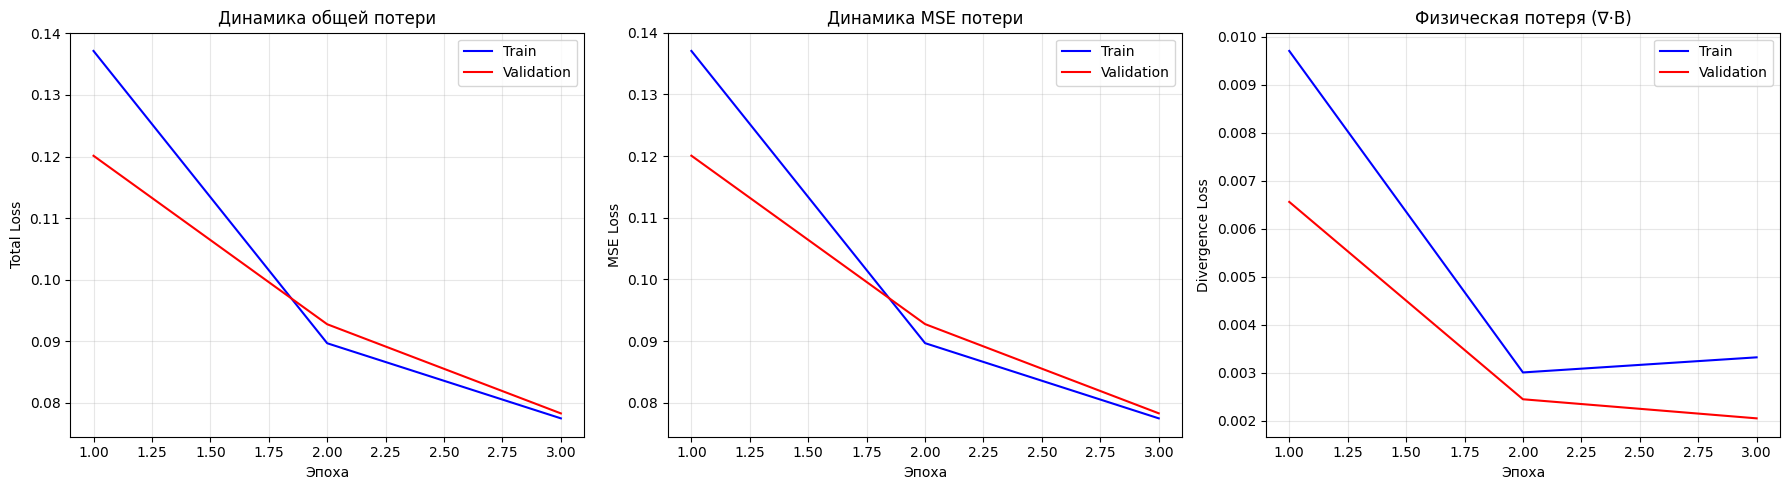


Лучший результат:
  Val Loss: 0.0783
  Val MSE: 0.0783


In [22]:
if (USE_THE_WELL or trajectories is not None) and 'history' in locals():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train')
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Validation')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Total Loss')
    axes[0].set_title('Динамика общей потери')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # MSE
    axes[1].plot(epochs, history['train_mse'], 'b-', label='Train')
    axes[1].plot(epochs, history['val_mse'], 'r-', label='Validation')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('MSE Loss')
    axes[1].set_title('Динамика MSE потери')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Divergence loss
    axes[2].plot(epochs, history['train_div'], 'b-', label='Train')
    axes[2].plot(epochs, history['val_div'], 'r-', label='Validation')
    axes[2].set_xlabel('Эпоха')
    axes[2].set_ylabel('Divergence Loss')
    axes[2].set_title('Физическая потеря (∇·B)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nЛучший результат:")
    print(f"  Val Loss: {min(history['val_loss']):.4f}")
    print(f"  Val MSE: {min(history['val_mse']):.4f}")

## 11. Оценка качества модели - одношаговое предсказание

In [23]:
def evaluate_single_step(model, dataset, device, n_samples=5):
    """Оценка одношагового предсказания"""
    model.eval()
    
    mae_list = []
    mse_list = []
    
    with torch.no_grad():
        for i in range(min(n_samples, len(dataset))):
            state, target = dataset[i]
            state = state.unsqueeze(0).to(device)
            target = target.unsqueeze(0).to(device)
            
            pred = model(state)
            
            mae = torch.abs(pred - target).mean().item()
            mse = ((pred - target) ** 2).mean().item()
            
            mae_list.append(mae)
            mse_list.append(mse)
    
    return {
        'mae_mean': np.mean(mae_list),
        'mae_std': np.std(mae_list),
        'mse_mean': np.mean(mse_list),
        'mse_std': np.std(mse_list)
    }

if USE_THE_WELL or trajectories is not None:
    # Загружаем лучшую модель
    model.load_state_dict(torch.load('mhd_unet_best.pth', map_location=device))
    print("✓ Загружена лучшая модель\n")
    
    # Оценка на валидационном наборе
    metrics = evaluate_single_step(model, val_dataset, device, n_samples=20)
    
    print("Метрики одношагового предсказания:")
    print(f"  MAE: {metrics['mae_mean']:.6f} ± {metrics['mae_std']:.6f}")
    print(f"  MSE: {metrics['mse_mean']:.6f} ± {metrics['mse_std']:.6f}")
    print(f"  RMSE: {np.sqrt(metrics['mse_mean']):.6f}")

✓ Загружена лучшая модель

Метрики одношагового предсказания:
  MAE: 0.115408 ± 0.002047
  MSE: 0.022901 ± 0.001022
  RMSE: 0.151331


## 12. Автоматический rollout - многошаговое предсказание

Самый важный тест: насколько модель может предсказывать эволюцию системы на много шагов вперед, используя свои предыдущие предсказания как вход.

In [26]:
def rollout_prediction(model, initial_state, n_steps, device, mean, std):
    """
    Авторегрессивное предсказание на n_steps шагов вперед.
    
    initial_state: (6, nx, ny, nz) начальное состояние
    """
    model.eval()
    
    trajectory = [initial_state.copy()]
    current_state = torch.from_numpy(initial_state).float().unsqueeze(0).to(device)
    
    # Нормализация
    current_state = (current_state - torch.from_numpy(mean).float().to(device)) / torch.from_numpy(std).float().to(device)
    
    with torch.no_grad():
        for step in range(n_steps):
            # Предсказываем изменение
            delta = model(current_state)
            
            # Денормализация и добавление к текущему состоянию
            current_state_denorm = current_state * torch.from_numpy(std).float().to(device) + torch.from_numpy(mean).float().to(device)
            next_state = current_state_denorm + delta
            
            # Сохраняем
            trajectory.append(next_state.cpu().numpy()[0])
            
            # Обновляем текущее состояние (с нормализацией)
            current_state = (next_state - torch.from_numpy(mean).float().to(device)) / torch.from_numpy(std).float().to(device)
    
    return np.array(trajectory)  # (n_steps+1, 6, nx, ny, nz)

def compute_rollout_errors(pred_trajectory, true_trajectory):
    """Вычисляет ошибки для каждого шага rollout"""
    errors = []
    for t in range(min(len(pred_trajectory), len(true_trajectory))):
        mse = ((pred_trajectory[t] - true_trajectory[t]) ** 2).mean()
        errors.append(mse)
    return np.array(errors)

# Rollout для The Well датасета
if USE_THE_WELL:
    print("Выполняем rollout предсказание для The Well датасета...\n")
    
    # Берем несколько последовательных образцов для создания траектории
    n_rollout_steps = min(10, len(val_dataset) - 1)
    
    # Получаем начальное состояние
    initial_state, _ = val_dataset[0]
    initial_state_np = initial_state.numpy()
    
    # Собираем истинную траекторию из последовательных образцов
    print(f"Сборка истинной траектории из {n_rollout_steps + 1} образцов...")
    true_trajectory = [initial_state_np]
    
    for i in range(1, n_rollout_steps + 1):
        sample = val_dataset_well[i]
        output_fields = sample['output_fields']  # (1, 64, 64, 64, 7)
        fields = output_fields[0].permute(3, 0, 1, 2).numpy()[:6]  # (6, 64, 64, 64)
        true_trajectory.append(fields)
    
    true_trajectory = np.array(true_trajectory)
    print(f"  Размер истинной траектории: {true_trajectory.shape}")
    
    # Предсказание траектории моделью
    print(f"\nПредсказание траектории на {n_rollout_steps} шагов...")
    pred_trajectory = rollout_prediction(
        model, initial_state_np, n_rollout_steps, device,
        train_dataset.mean[0], train_dataset.std[0]
    )
    
    # Вычисляем ошибки
    errors = compute_rollout_errors(pred_trajectory, true_trajectory)
    
    print(f"\n✓ Rollout завершен")
    print(f"Ошибки по шагам (MSE):")
    for t, err in enumerate(errors):
        print(f"  Шаг {t}: {err:.6f}")

# Rollout для синтетических данных
elif trajectories is not None:
    # Выбираем одну траекторию из валидационного набора
    traj_idx = 0
    val_traj = val_trajectories[traj_idx]
    
    # Берем начальное состояние
    v_init = val_traj['v'][0]
    B_init = val_traj['B'][0]
    initial_state = np.concatenate([v_init, B_init], axis=0)
    
    # Истинная траектория
    true_v = val_traj['v']
    true_B = val_traj['B']
    true_trajectory = np.concatenate([true_v, true_B], axis=1)  # (T, 6, nx, ny, nz)
    
    # Rollout prediction
    n_rollout_steps = min(10, true_v.shape[0] - 1)
    print(f"Выполняем rollout на {n_rollout_steps} шагов...")
    
    pred_trajectory = rollout_prediction(
        model, initial_state, n_rollout_steps, device,
        train_dataset.mean[0], train_dataset.std[0]
    )
    
    # Вычисляем ошибки
    errors = compute_rollout_errors(pred_trajectory, true_trajectory[:n_rollout_steps+1])
    
    print(f"\n✓ Rollout завершен")
    print(f"Ошибки по шагам (MSE):")
    for t, err in enumerate(errors):
        print(f"  Шаг {t}: {err:.6f}")


Выполняем rollout предсказание для The Well датасета...

Сборка истинной траектории из 11 образцов...
  Размер истинной траектории: (11, 6, 64, 64, 64)

Предсказание траектории на 10 шагов...

✓ Rollout завершен
Ошибки по шагам (MSE):
  Шаг 0: 0.000000
  Шаг 1: 0.899041
  Шаг 2: 0.997500
  Шаг 3: 1.118568
  Шаг 4: 1.259620
  Шаг 5: 1.425816
  Шаг 6: 1.634154
  Шаг 7: 1.882345
  Шаг 8: 2.193984
  Шаг 9: 2.591867
  Шаг 10: 3.107183


## 13. Визуализация результатов rollout

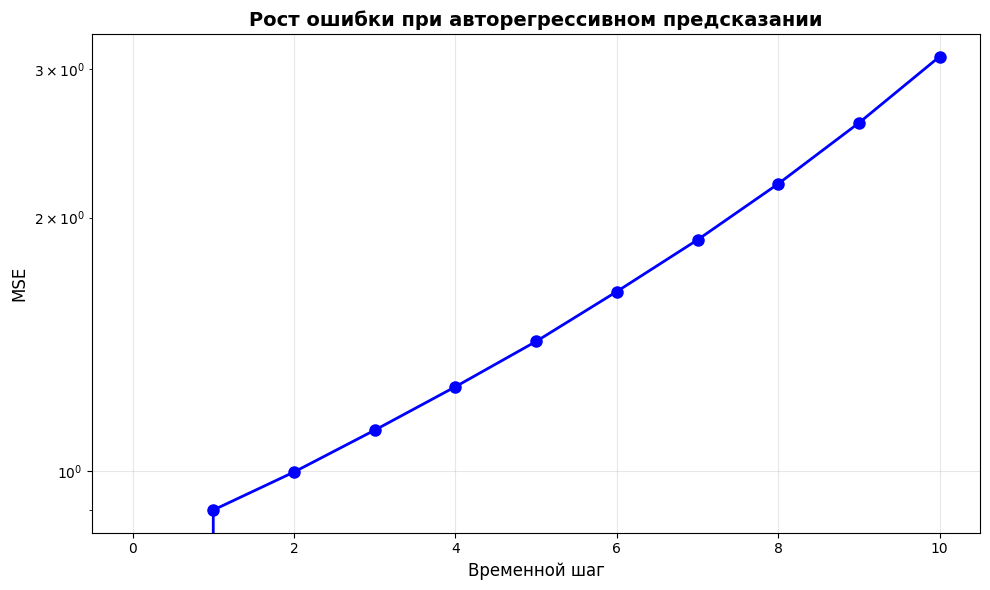

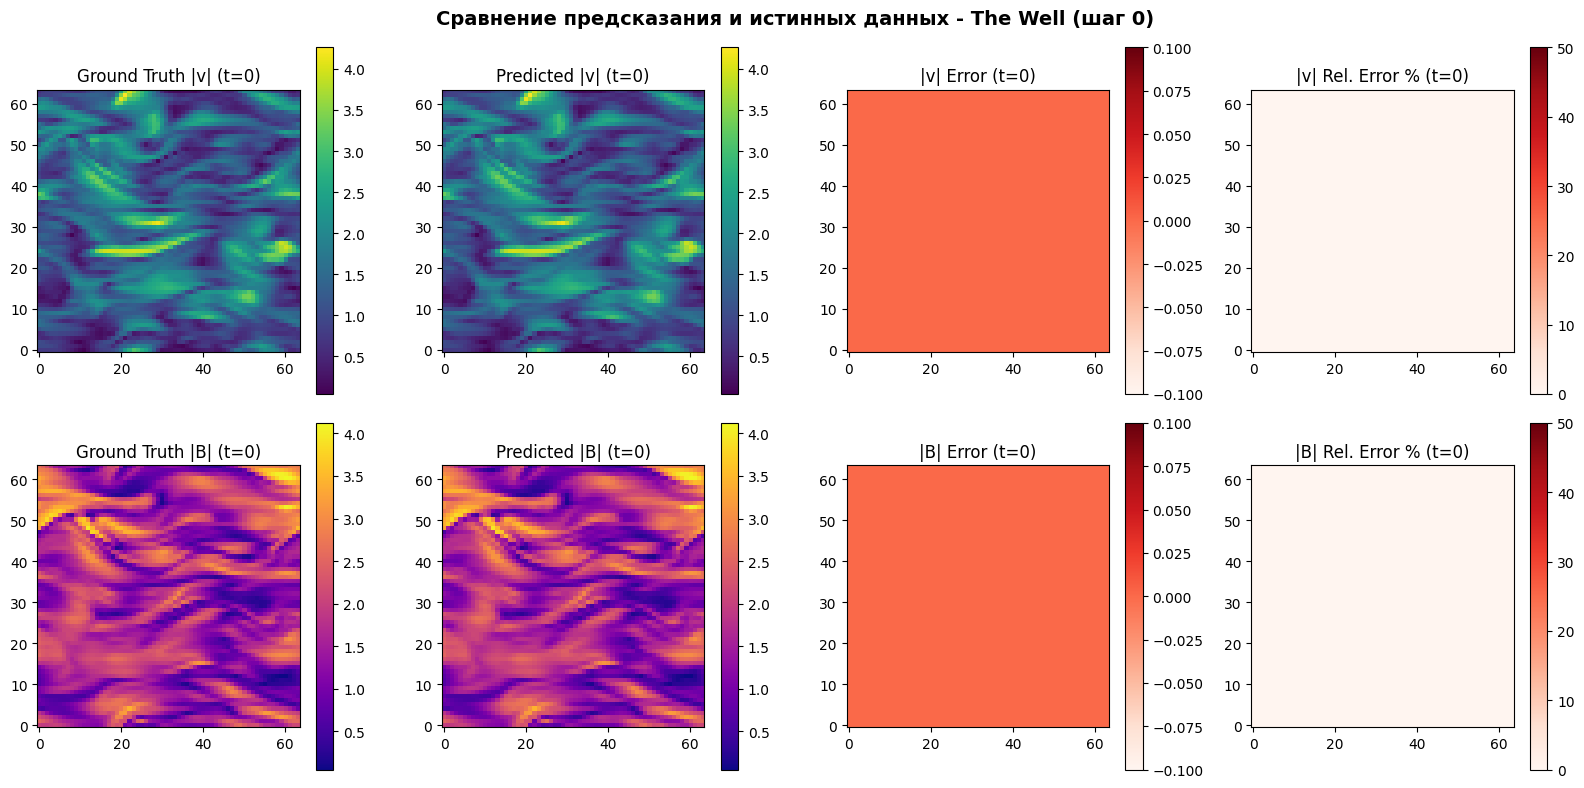

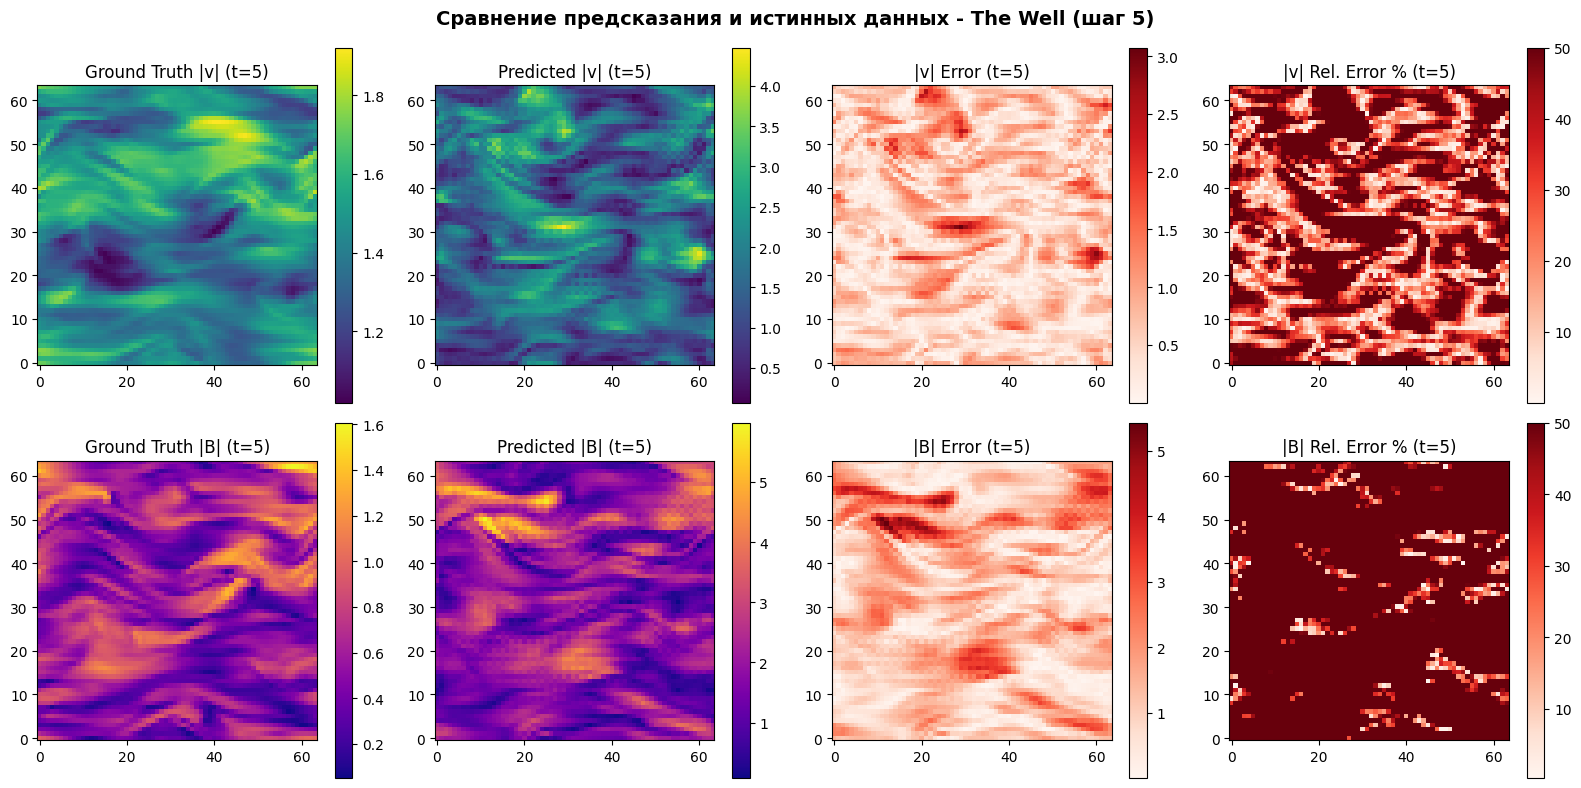

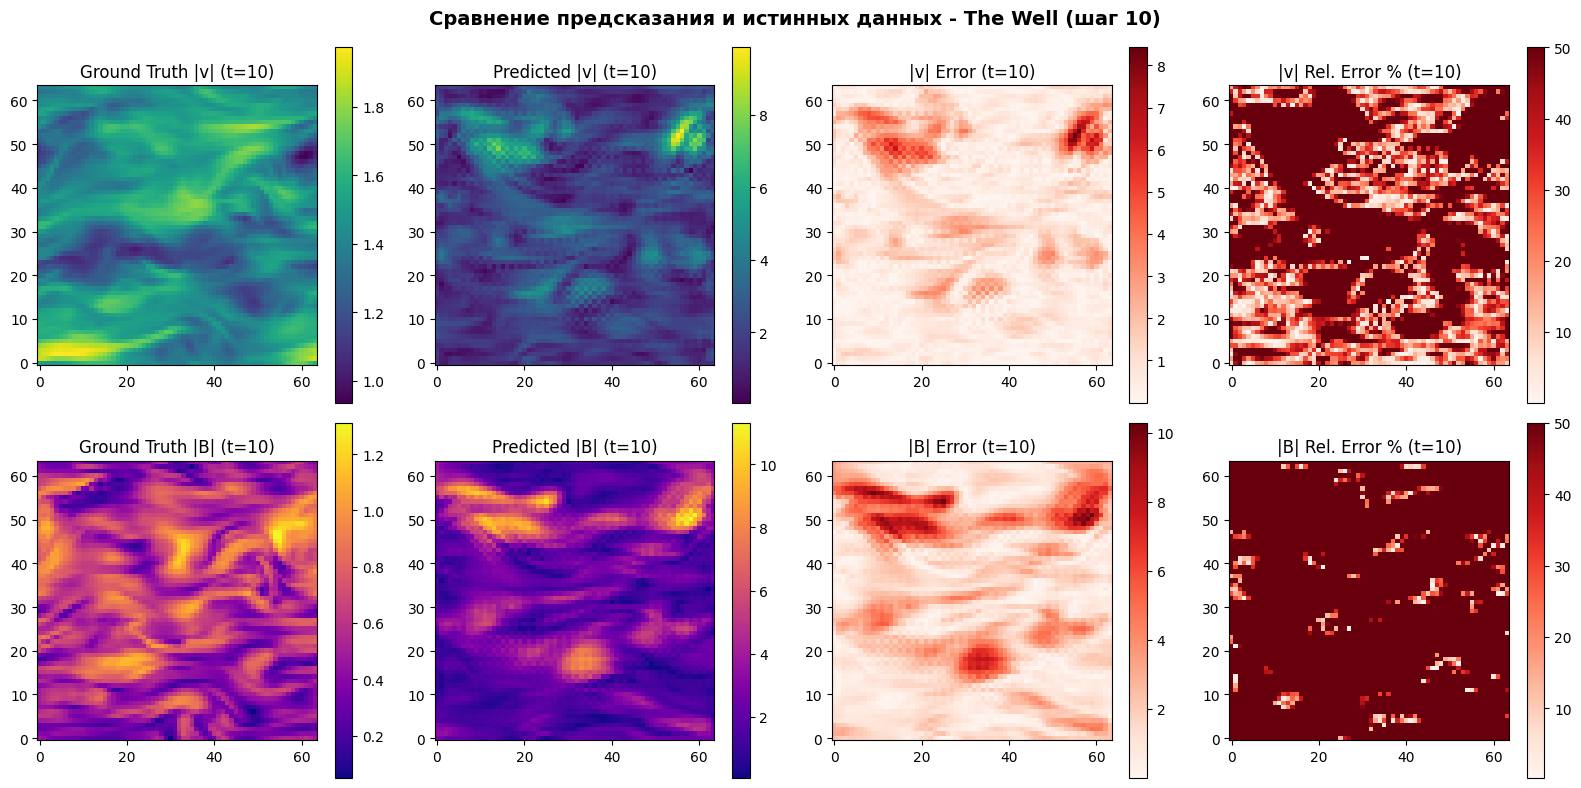

In [27]:
if (USE_THE_WELL or trajectories is not None) and 'pred_trajectory' in locals():
    # График ошибок rollout
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    ax.plot(range(len(errors)), errors, 'b-o', linewidth=2, markersize=8)
    ax.set_xlabel('Временной шаг', fontsize=12)
    ax.set_ylabel('MSE', fontsize=12)
    ax.set_title('Рост ошибки при авторегрессивном предсказании', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Сравнение предсказанных и истинных полей на разных шагах
    compare_steps = [0, n_rollout_steps // 2, n_rollout_steps]
    
    dataset_name = "The Well" if USE_THE_WELL else "Synthetic"
    
    for step_idx in compare_steps:
        if step_idx < len(pred_trajectory):
            pred_state = pred_trajectory[step_idx]
            true_state = true_trajectory[step_idx]
            
            # Разделяем на v и B
            pred_v = pred_state[:3]
            pred_B = pred_state[3:]
            true_v = true_state[:3]
            true_B = true_state[3:]
            
            # Визуализация
            nz = pred_v.shape[-1]
            z_slice = nz // 2
            
            fig, axes = plt.subplots(2, 4, figsize=(16, 8))
            
            # Истинные поля
            v_mag_true = np.sqrt((true_v**2).sum(axis=0))
            B_mag_true = np.sqrt((true_B**2).sum(axis=0))
            
            im0 = axes[0, 0].imshow(v_mag_true[:, :, z_slice].T, origin='lower', cmap='viridis')
            axes[0, 0].set_title(f'Ground Truth |v| (t={step_idx})')
            plt.colorbar(im0, ax=axes[0, 0])
            
            im1 = axes[1, 0].imshow(B_mag_true[:, :, z_slice].T, origin='lower', cmap='plasma')
            axes[1, 0].set_title(f'Ground Truth |B| (t={step_idx})')
            plt.colorbar(im1, ax=axes[1, 0])
            
            # Предсказанные поля
            v_mag_pred = np.sqrt((pred_v**2).sum(axis=0))
            B_mag_pred = np.sqrt((pred_B**2).sum(axis=0))
            
            im2 = axes[0, 1].imshow(v_mag_pred[:, :, z_slice].T, origin='lower', cmap='viridis')
            axes[0, 1].set_title(f'Predicted |v| (t={step_idx})')
            plt.colorbar(im2, ax=axes[0, 1])
            
            im3 = axes[1, 1].imshow(B_mag_pred[:, :, z_slice].T, origin='lower', cmap='plasma')
            axes[1, 1].set_title(f'Predicted |B| (t={step_idx})')
            plt.colorbar(im3, ax=axes[1, 1])
            
            # Ошибки
            v_error = np.abs(v_mag_pred - v_mag_true)
            B_error = np.abs(B_mag_pred - B_mag_true)
            
            im4 = axes[0, 2].imshow(v_error[:, :, z_slice].T, origin='lower', cmap='Reds')
            axes[0, 2].set_title(f'|v| Error (t={step_idx})')
            plt.colorbar(im4, ax=axes[0, 2])
            
            im5 = axes[1, 2].imshow(B_error[:, :, z_slice].T, origin='lower', cmap='Reds')
            axes[1, 2].set_title(f'|B| Error (t={step_idx})')
            plt.colorbar(im5, ax=axes[1, 2])
            
            # Относительная ошибка (%)
            v_rel_error = 100 * v_error / (v_mag_true + 1e-8)
            B_rel_error = 100 * B_error / (B_mag_true + 1e-8)
            
            im6 = axes[0, 3].imshow(v_rel_error[:, :, z_slice].T, origin='lower', cmap='Reds', vmax=50)
            axes[0, 3].set_title(f'|v| Rel. Error % (t={step_idx})')
            plt.colorbar(im6, ax=axes[0, 3])
            
            im7 = axes[1, 3].imshow(B_rel_error[:, :, z_slice].T, origin='lower', cmap='Reds', vmax=50)
            axes[1, 3].set_title(f'|B| Rel. Error % (t={step_idx})')
            plt.colorbar(im7, ax=axes[1, 3])
            
            fig.suptitle(f'Сравнение предсказания и истинных данных - {dataset_name} (шаг {step_idx})', 
                        fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

## 14. Выводы и дальнейшие улучшения

### Что мы реализовали:

1. ✓ Загрузку реальных данных МГД из датасета The Well
2. ✓ Понимание физики уравнений МГД (уравнение движения + индукции)
3. ✓ 3D U-Net архитектуру для предсказания эволюции МГД систем
4. ✓ Физически-информированные функции потерь (MSE + ∇·B constraint)
5. ✓ Обучение модели с валидацией и сохранением лучшей модели
6. ✓ Оценку одношагового и многошагового (rollout) предсказания
7. ✓ Визуализацию результатов и анализ ошибок

### Возможные улучшения:

1. **Архитектура:**
   - Fourier Neural Operator (FNO) - работает в спектральном пространстве
   - Transformer-based архитектуры для временных зависимостей
   - Physics-Informed Neural Networks (PINN) с встроенными уравнениями

2. **Физические ограничения:**
   - Точное сохранение ∇·B = 0 (бездивергентность)
   - Энергетические законы сохранения
   - Гельмгольцова декомпозиция полей

3. **Данные:**
   - Использование полного датасета The Well (размер 64³ или больше)
   - Аугментация данных (вращения, отражения)
   - Мультимасштабное обучение

4. **Обучение:**
   - Curriculum learning (от простых к сложным траекториям)
   - Teacher forcing vs. free running режимы
   - Длинные rollout последовательности

### Физическая интерпретация:

Модель учится предсказывать:
- **Адвекцию**: перенос полей потоком $(\mathbf{v}\cdot\nabla)\mathbf{v}$
- **Силу Лоренца**: взаимодействие тока и магнитного поля $\mathbf{j}\times\mathbf{B}$
- **Вмороженность**: перенос магнитного поля $\nabla\times(\mathbf{v}\times\mathbf{B})$
- **Диффузию**: сглаживание полей $\nu\nabla^2\mathbf{v}$, $\eta\nabla^2\mathbf{B}$

Это позволяет ускорить симуляции МГД в задачах астрофизики, термоядерного синтеза и геофизики!